what is the longest match recorded in terms of duration?

step1:import libraries

In [38]:

import polars as pl
from pathlib import Path 


stap2:define project path

In [39]:
CURRENT_DIR=Path.cwd()

PROJECT_PATH=CURRENT_DIR.parent

print("project_path:",PROJECT_PATH)


project_path: /Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis


step3: locate parquet files

In [40]:
# Search all parquet files in the whole project
all_parquet_files = list(PROJECT_PATH.rglob("*.parquet"))

# Show all found parquet files
all_parquet_files

[PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tournament_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/statistics_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/event.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/season_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tennis_power_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/votes_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/time_clean.parquet'),
 PosixPath('/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/D

step 4:define data path

In [41]:
# List all parquet files in Data folder

data_path = PROJECT_PATH / "tennis_data" / "Data"

parquet_files=list(data_path.rglob("*.parquet"))

for file in parquet_files:
    print(file)
    
    
print("\nData_path:",data_path)

print("\nfolder exists:",data_path.exists())

/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tournament_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/statistics_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/event.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/season_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/tennis_power_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/votes_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/time_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/venue_clean.parquet
/Users/macbook/Desktop/ data_analysis_tannis projects/tennis_data_analysis/tennis_data/Data/o

In [42]:
import polars as pl

duration_files = []

for file in data_path.rglob("*.parquet"):
    try:
        df = pl.read_parquet(file, n_rows=1)

        for col in df.columns:
            if "duration" in col.lower():
                duration_files.append((file.name, col))
                print(file.name, "---->", col)

    except:
        pass

duration_files

[]

In [43]:
time_files = []

for file in data_path.rglob("*.parquet"):
    try:
        df = pl.read_parquet(file, n_rows=1)

        for col in df.columns:
            if any(word in col.lower() for word in ["time", "second", "minute", "length"]):
                time_files.append((file.name, col))
                print(file.name, "---->", col)

    except:
        pass

time_files

event.parquet ----> start_datetime
event.parquet ----> match_datetime
time_clean.parquet ----> current_period_start_timestamp
home_team_score.parquet ----> normal_time
away_team_score.parquet ----> normal_time


[('event.parquet', 'start_datetime'),
 ('event.parquet', 'match_datetime'),
 ('time_clean.parquet', 'current_period_start_timestamp'),
 ('home_team_score.parquet', 'normal_time'),
 ('away_team_score.parquet', 'normal_time')]

In [44]:

home_score = pl.read_parquet(
    data_path / "away_and_home_score"/"home_team_score.parquet"
)

away_score = pl.read_parquet(
    data_path /"away_and_home_score" /"away_team_score.parquet"
)

In [45]:
home_score.select(
    "normal_time"
).describe()

statistic,normal_time
str,f64
"""count""",0.0
"""null_count""",35164.0
"""mean""",null
"""std""",null
"""min""",null
"""25%""",null
"""50%""",null
"""75%""",null
"""max""",null


In [46]:
away_score.select(
    "normal_time"
).describe()

statistic,normal_time
str,f64
"""count""",0.0
"""null_count""",35053.0
"""mean""",null
"""std""",null
"""min""",null
"""25%""",null
"""50%""",null
"""75%""",null
"""max""",null


step5:load time dataset

In [47]:
# Define the path to the cleaned Time dataset
time_path = PROJECT_PATH / "tennis_data" / "Data" / "time_clean.parquet"

# Load the cleaned Time dataset
time= pl.read_parquet(time_path)

# Display the first few rows
time.head()


match_id,period_1,period_2,period_3,period_4,period_5,current_period_start_timestamp,snapshot_date
i64,i64,i64,i64,i64,i64,i64,date
11974053,null,null,null,null,null,null,2024-02-01
11974066,null,null,null,null,null,null,2024-02-01
11998445,3259,2639,4202,null,null,1706816851,2024-02-01
11998446,2488,2375,null,null,null,1706803981,2024-02-01
11998447,3741,1913,null,null,null,1706798459,2024-02-01


In [48]:
time = time.unique(
    ["match_id"]
)

In [49]:
time_unique = time.with_columns(
    (
        pl.col("period_1").fill_null(0)
        + pl.col("period_2").fill_null(0)
        + pl.col("period_3").fill_null(0)
        + pl.col("period_4").fill_null(0)
        + pl.col("period_5").fill_null(0)
    ).alias("duration_seconds")
)

In [55]:
time_unique = time_unique.with_columns(
    (
        pl.col("duration_seconds") / 60
    ).alias("match_duration_minutes")
)

In [57]:
time_unique.select(
    "match_duration_minutes"
).describe()

statistic,match_duration_minutes
str,f64
"""count""",16873.0
"""null_count""",0.0
"""mean""",70.223182
"""std""",132.679758
"""min""",0.0
"""25%""",0.0
"""50%""",71.833333
"""75%""",105.233333
"""max""",5613.166667


In [58]:
duration_clean = time_unique.filter(
    (pl.col("match_duration_minutes") > 0) &
    (pl.col("match_duration_minutes") <= 300)
)

In [59]:
duration_clean.sort(
    "match_duration_minutes",
    descending=True
).head(10)

match_id,period_1,period_2,period_3,period_4,period_5,current_period_start_timestamp,snapshot_date,duration_seconds,match_duration_minutes
i64,i64,i64,i64,i64,i64,i64,date,i64,f64
12056393,5296,7198,5340,null,null,1707571561,2024-02-09,17834,297.233333
12172233,3963,10621,3133,null,null,1710911590,2024-03-19,17717,295.283333
12170628,2821,13335,1535,null,null,1710848659,2024-03-18,17691,294.85
12131381,1930,15656,null,null,null,1709864964,2024-03-07,17586,293.1
12137174,2320,1230,13849,null,null,1709901873,2024-03-07,17399,289.983333
12197940,13584,3374,null,null,null,1711568177,2024-03-27,16958,282.633333
12174579,6033,8100,2226,null,null,1710962143,2024-03-20,16359,272.65
12194086,4200,2520,9486,null,null,1711462024,2024-03-25,16206,270.1
12173290,2555,13559,null,null,null,1710904985,2024-03-19,16114,268.566667


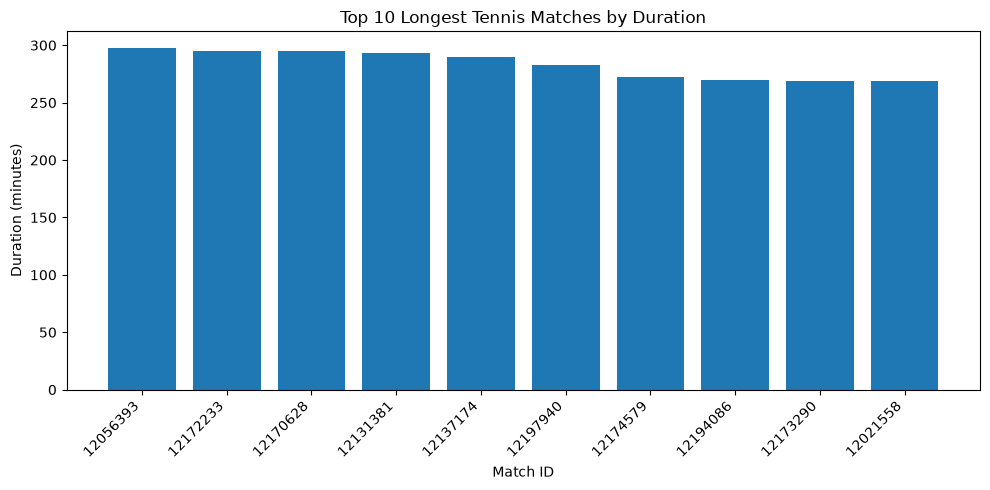

In [62]:
import matplotlib.pyplot as plt

# Select top 10 longest matches
longest_matches = (
    duration_clean
    .sort(
        "match_duration_minutes",
        descending=True
    )
    .head(10)
    .to_pandas()
)

plt.figure(figsize=(10,5))

plt.bar(
    longest_matches["match_id"].astype(str),
    longest_matches["match_duration_minutes"]
)

plt.xlabel("Match ID")
plt.ylabel("Duration (minutes)")
plt.title("Top 10 Longest Tennis Matches by Duration")

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

## Objective

The objective of this analysis is to identify the longest recorded tennis match based on match duration.

## Data Used

The match duration was calculated using the time information from:

- MatchTimeInfo

The following columns were used:

- match_id
- period_1
- period_2
- period_3
- period_4
- period_5

These columns represent the duration values recorded for different periods of a match.

## Data Preparation

First, the duration of each match was calculated by summing all available period durations:

- Missing period values were replaced with zero.
- The total duration was calculated by adding all periods.
- The duration values were converted from seconds to minutes.

Formula:

Duration (minutes) = (Period 1 + Period 2 + Period 3 + Period 4 + Period 5) / 60

## Data Cleaning

Some records contained unrealistic duration values caused by abnormal time records.

To improve the reliability of the analysis:

- Non-positive durations were removed.
- Extremely long durations above 300 minutes were excluded as outliers.

The final analysis was performed on the cleaned duration dataset.

## Method

After cleaning the data, matches were sorted based on match_duration_minutes in descending order.

The match with the highest duration was selected as the longest recorded match.

## Result

The longest match was identified based on the maximum value of match_duration_minutes in the cleaned dataset.

## Conclusion

This analysis identifies the longest recorded tennis match in the dataset after removing invalid and unrealistic duration values.

The result represents the longest meaningful match duration available in the dataset.